# Amazon Product Analysis

## Project Overview

This project analyzes Amazon product data to understand:

- Product distribution
- Pricing
- Discounts
- Customer savings
- Product ratings
- Customer engagement
- Relationship between discount and rating

### Tools Used
- Python
- Pandas
- Matplotlib

In [12]:
import pandas as pd
from sqlalchemy import create_engine


In [13]:
username = ""
password = ""
host = ""
database = ""

In [14]:
engine = create_engine(
    f"mysql+pymysql://{""}:{""}@{""}/{""}"
)

In [15]:
connection = engine.connect()

print("MySQL Connected Successfully!")

MySQL Connected Successfully!


In [16]:
query = "SELECT * FROM amazon"

df = pd.read_sql(query, engine)

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

In [18]:
df.head()

,product_id,category,sub_category,discounted_price,actual_price,discount_percentage,rating,rating_count,After_discount
0,B07JW9H4J1,Cables,USBCables,399,1099,0.64,4.2,24269,700
1,B098NS6PVG,Cables,USBCables,199,349,0.43,4.0,43994,150
2,B096MSW6CT,Cables,USBCables,199,1899,0.90,3.9,7928,1700
3,B08HDJ86NZ,Cables,USBCables,329,699,0.53,4.2,94363,370
4,B08CF3B7N1,Cables,USBCables,154,399,0.61,4.2,16905,245


In [19]:
df.shape

(1381, 9)

In [22]:
df.tail

<bound method NDFrame.tail of       product_id                  category sub_category  discounted_price  \
0     B07JW9H4J1                    Cables    USBCables               399   
1     B098NS6PVG                    Cables    USBCables               199   
2     B096MSW6CT                    Cables    USBCables               199   
3     B08HDJ86NZ                    Cables    USBCables               329   
4     B08CF3B7N1                    Cables    USBCables               154   
...          ...                       ...          ...               ...   
1376  B08L7J3T31  WaterPurifierAccessories      Unknown               379   
1377  B01M6453MB         Rice&PastaCookers      Unknown              2280   
1378  B009P2LIL4            HeatConvectors      Unknown              2219   
1379  B00J5DYCCA               ExhaustFans      Unknown              1399   
1380  B01486F4G6            SandwichMakers      Unknown              2863   

      actual_price  discount_percentage  rati

In [23]:
df.info

<bound method DataFrame.info of       product_id                  category sub_category  discounted_price  \
0     B07JW9H4J1                    Cables    USBCables               399   
1     B098NS6PVG                    Cables    USBCables               199   
2     B096MSW6CT                    Cables    USBCables               199   
3     B08HDJ86NZ                    Cables    USBCables               329   
4     B08CF3B7N1                    Cables    USBCables               154   
...          ...                       ...          ...               ...   
1376  B08L7J3T31  WaterPurifierAccessories      Unknown               379   
1377  B01M6453MB         Rice&PastaCookers      Unknown              2280   
1378  B009P2LIL4            HeatConvectors      Unknown              2219   
1379  B00J5DYCCA               ExhaustFans      Unknown              1399   
1380  B01486F4G6            SandwichMakers      Unknown              2863   

      actual_price  discount_percentage  ra

In [24]:
df.describe

<bound method NDFrame.describe of       product_id                  category sub_category  discounted_price  \
0     B07JW9H4J1                    Cables    USBCables               399   
1     B098NS6PVG                    Cables    USBCables               199   
2     B096MSW6CT                    Cables    USBCables               199   
3     B08HDJ86NZ                    Cables    USBCables               329   
4     B08CF3B7N1                    Cables    USBCables               154   
...          ...                       ...          ...               ...   
1376  B08L7J3T31  WaterPurifierAccessories      Unknown               379   
1377  B01M6453MB         Rice&PastaCookers      Unknown              2280   
1378  B009P2LIL4            HeatConvectors      Unknown              2219   
1379  B00J5DYCCA               ExhaustFans      Unknown              1399   
1380  B01486F4G6            SandwichMakers      Unknown              2863   

      actual_price  discount_percentage  

In [25]:
df.isnull().sum()

product_id             0
category               0
sub_category           0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           0
After_discount         0
dtype: int64

In [26]:
df.duplicated().sum()

np.int64(0)

In [28]:
df["category"].value_counts()


category
Cables                        205
Unknown                       161
Smartphones                    68
SmartTelevisions               61
Irons,Steamers&Accessories     58
                             ... 
Basic                           1
Cleaners                        1
Film                            1
Caddies                         1
PedestalFans                    1
Name: count, Length: 137, dtype: int64

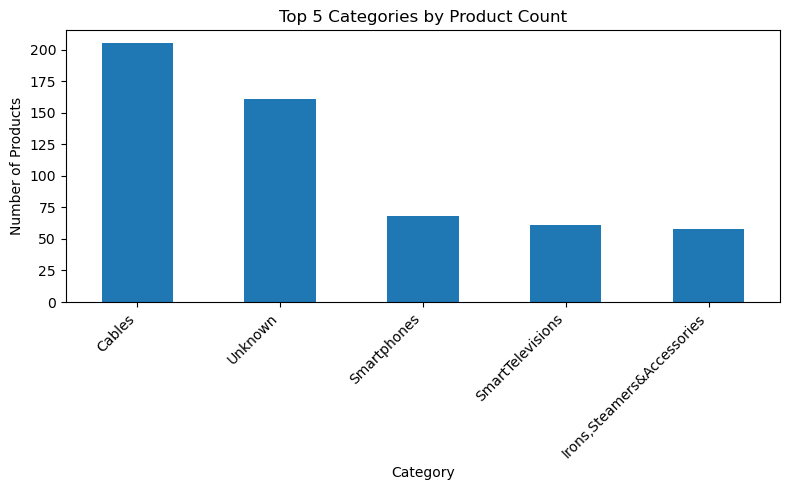

In [76]:
category_count = df["category"].value_counts().head(5)

plt.figure(figsize=(8,5))
category_count.plot(kind="bar")

plt.title("Top 5 Categories by Product Count")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

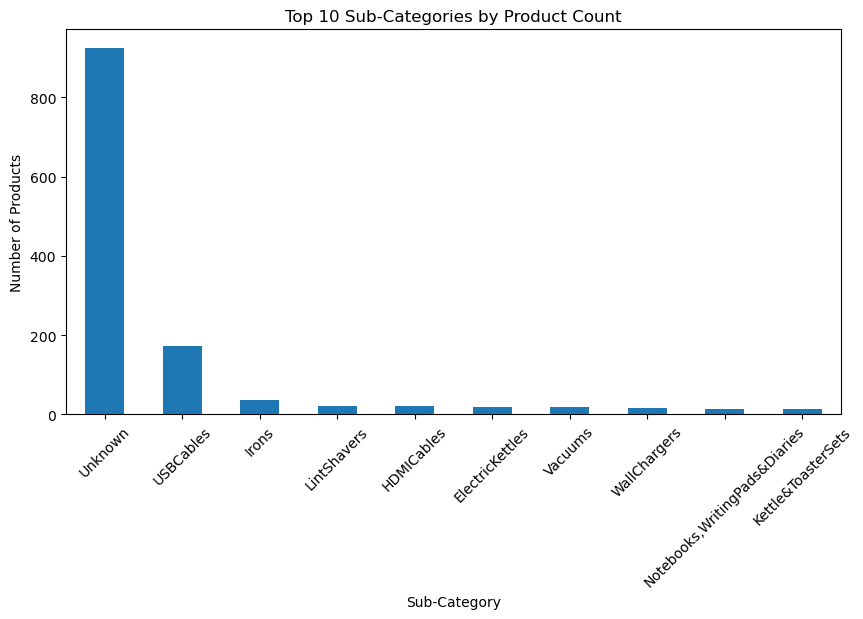

In [30]:
sub_category_count = df["sub_category"].value_counts()

sub_category_count.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Sub-Categories by Product Count")
plt.xlabel("Sub-Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)
plt.show()

In [40]:
avg_price = df.groupby("category")["discounted_price"].mean().sort_values(ascending=False).head(5)

print(avg_price)


category
Split-SystemAirConditioners    42990.000000
SmartTelevisions               25212.327869
Smartphones                    15754.441176
HEPAAirPurifiers               11917.000000
StandardTelevisions             7180.833333
Name: discounted_price, dtype: float64


In [35]:
df.columns

Index(['product_id', 'category', 'sub_category', 'discounted_price',
       'actual_price', 'discount_percentage', 'rating', 'rating_count',
       'After_discount'],
      dtype='object')

In [45]:
total_savings = df["customer_savings"].sum()

print("Total Customer Savings:", total_savings)

Total Customer Savings: 3318437


In [48]:
avg_savings = df["customer_savings"].mean()

print("Average Customer Savings:", avg_savings)

Average Customer Savings: 2402.923244026068


In [52]:
category_savings = (
    df.groupby("category")["customer_savings"]
    .sum()
    .sort_values(ascending=False).head(5))

print(category_savings)

category
SmartTelevisions          945527
Unknown                   637987
Smartphones               329049
Cables                    119952
WaterFilters&Purifiers    103243
Name: customer_savings, dtype: int64


In [53]:
avg_rating = (
    df.groupby("category")["rating"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_rating)

category
Basic               4.5
CoffeePresses       4.5
StreamingClients    4.5
Film                4.5
PowerLANAdapters    4.5
                   ... 
InkjetPrinters      3.6
PCMicrophones       3.6
PCHeadsets          3.5
3DGlasses           3.5
CoffeeGrinders      3.3
Name: rating, Length: 137, dtype: float64


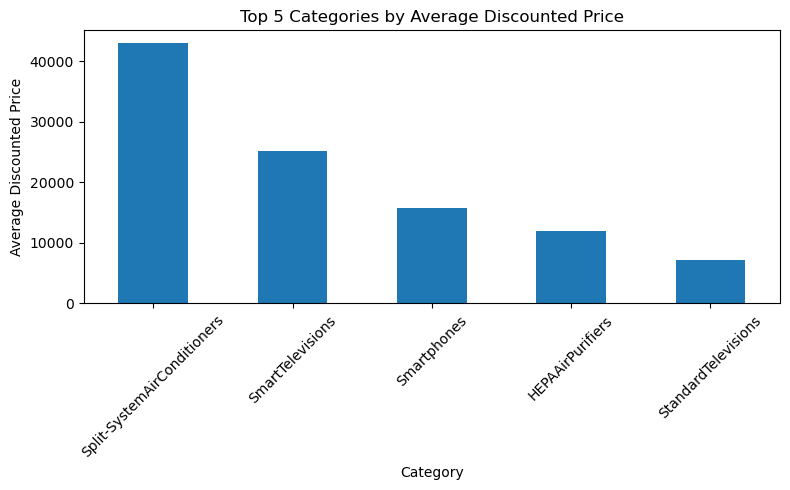

In [70]:
top5 = df.groupby("category")["discounted_price"].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
top5.plot(kind="bar")
plt.title("Top 5 Categories by Average Discounted Price")
plt.xlabel("Category")
plt.ylabel("Average Discounted Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

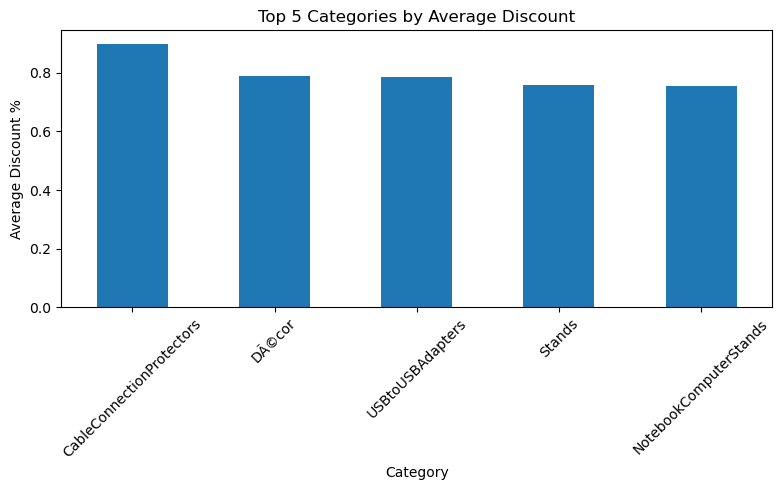

In [71]:
top5 = df.groupby("category")["discount_percentage"].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
top5.plot(kind="bar")
plt.title("Top 5 Categories by Average Discount")
plt.xlabel("Category")
plt.ylabel("Average Discount %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

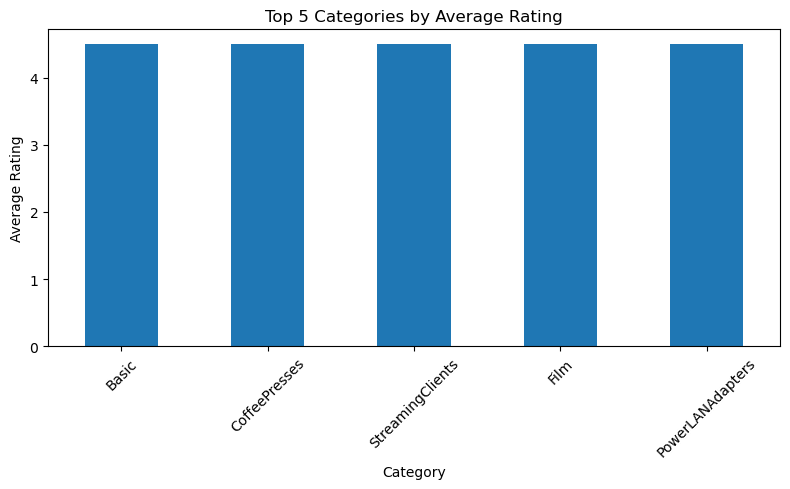

In [72]:
top5 = df.groupby("category")["rating"].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
top5.plot(kind="bar")
plt.title("Top 5 Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [57]:
engagement = (
    df.groupby("category")["rating_count"]
    .sum()
    .sort_values(ascending=False).head(10)
)

print(engagement)

category
Cables                 4768322
In-Ear                 4204939
Unknown                3798848
Smartphones            2493269
MicroSD                1080967
Chargers                859193
SmartTelevisions        732004
WirelessUSBAdapters     671975
BasicMobiles            550259
On-Ear                  542870
Name: rating_count, dtype: int64


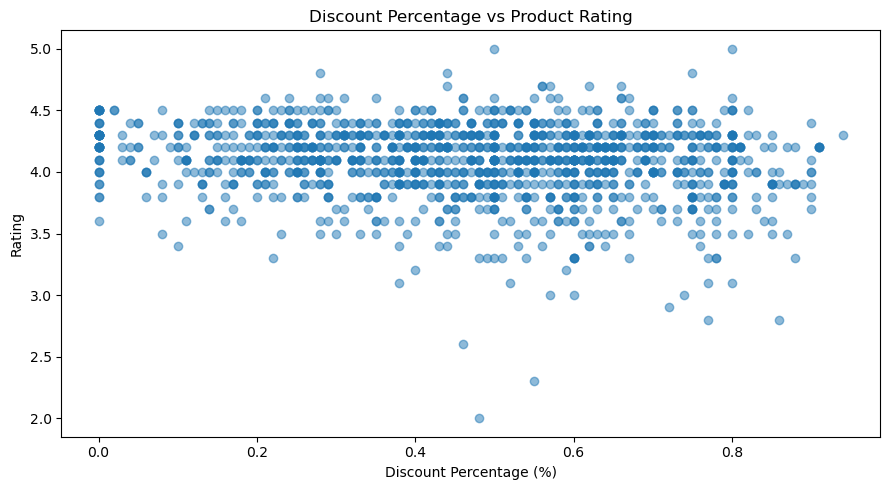

In [69]:
plt.figure(figsize=(9,5))

plt.scatter(
    df["discount_percentage"],
    df["rating"],
    alpha=0.5
)

plt.title("Discount Percentage vs Product Rating")
plt.xlabel("Discount Percentage (%)")
plt.ylabel("Rating")
plt.tight_layout()
plt.show()

In [59]:
correlation = df["discount_percentage"].corr(df["rating"])

print("Correlation between Discount and Rating:", correlation)

Correlation between Discount and Rating: -0.1581745115691228


In [60]:
if correlation > 0:
    print("Positive relationship between discount and rating.")
elif correlation < 0:
    print("Negative relationship between discount and rating.")
else:
    print("No linear relationship between discount and rating.")

Negative relationship between discount and rating.


In [61]:
top_rated = df.sort_values(
    by="rating",
    ascending=False
).head(10)

print(top_rated[["product_id", "category", "rating"]])

      product_id                    category  rating
726   B09ZHCJDP1                        Mice     5.0
174   B0BP7XLX48                      Cables     5.0
1215  B0B53DS4TF               DeepFatFryers     4.8
1062  B0BR4F878Q         InstantWaterHeaters     4.8
1118  B0BQ3K23Y1                HandBlenders     4.8
1140  B0BM4KTNL1                HandBlenders     4.7
1304  B0BP89YBC1         InstantWaterHeaters     4.7
249   B09WN3SRC7            SmartTelevisions     4.7
1192  B0BM9H2NY9                  EggBoilers     4.7
452   B0B23LW7NV  Maintenance,Upkeep&Repairs     4.7


In [62]:
top_discounted = df.sort_values(
    by="discount_percentage",
    ascending=False
).head(10)

print(top_discounted[
    ["product_id", "category", "discount_percentage"]
])

     product_id                   category  discount_percentage
659  B097C564GC           USBtoUSBAdapters                 0.94
362  B0BF54972T                    Unknown                 0.91
378  B0BF54LXW6                    Unknown                 0.91
370  B0BF4YBLPX                    Unknown                 0.91
366  B0BF563HB4                    Unknown                 0.91
332  B0BF57RN3K                    Unknown                 0.91
856  B08X77LM8C                    Unknown                 0.90
527  B09SJ1FTYV               Cases&Covers                 0.90
943  B0B61DSF17       DigitalKitchenScales                 0.90
584  B08W56G1K9  CableConnectionProtectors                 0.90


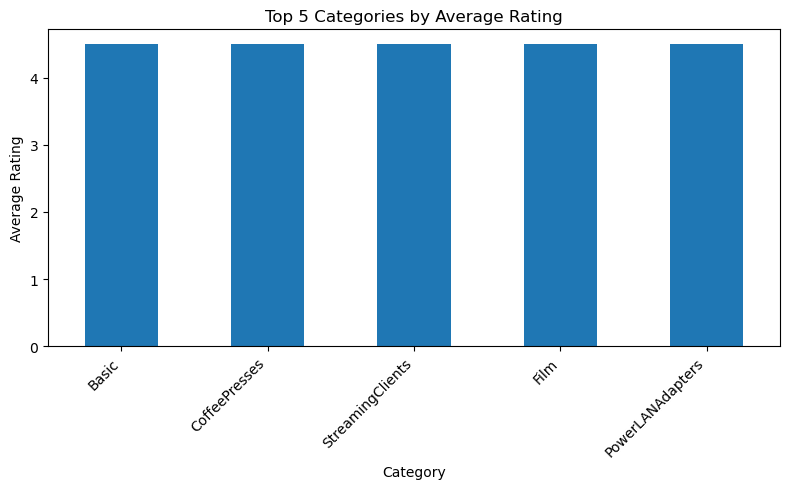

In [75]:
avg_rating = df.groupby("category")["rating"].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
avg_rating.plot(kind="bar")

plt.title("Top 5 Categories by Average Rating")
plt.xlabel("Category")
plt.ylabel("Average Rating")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

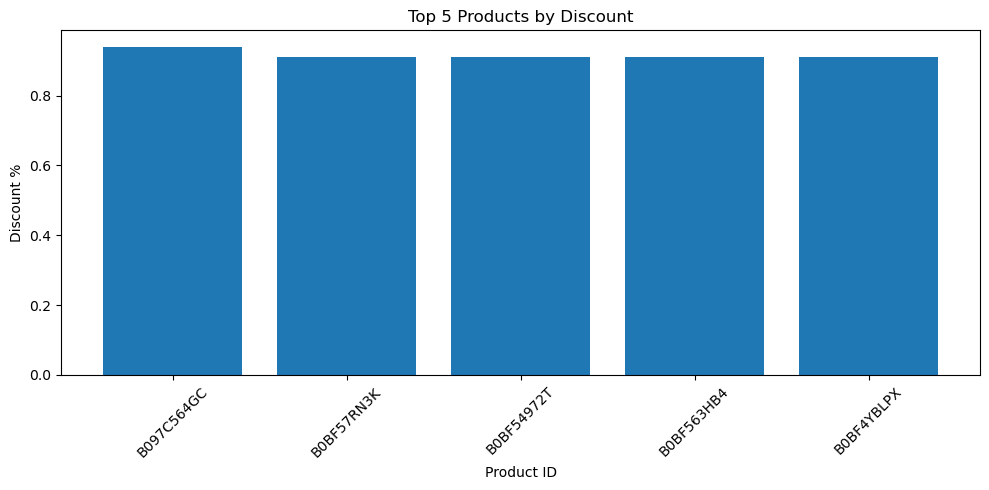

In [74]:
top5 = df.nlargest(5, "discount_percentage")

plt.figure(figsize=(10,5))
plt.bar(top5["product_id"].astype(str), top5["discount_percentage"])
plt.title("Top 5 Products by Discount")
plt.xlabel("Product ID")
plt.ylabel("Discount %")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()